In [ ]:
import pandas as pd

train = pd.read_csv("train.csv")
meal = pd.read_csv("meal_info.csv")
center = pd.read_csv("fulfilment_center_info.csv")

In [ ]:
df = pd.merge(train, meal, on="meal_id")

In [ ]:
df = pd.merge(df, center, on="center_id")

In [ ]:
print(df.shape)
print(df.columns)
print(df.head())
print(df.info())

(456548, 15)
Index(['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price',
       'emailer_for_promotion', 'homepage_featured', 'num_orders', 'category',
       'cuisine', 'city_code', 'region_code', 'center_type', 'op_area'],
      dtype='object')
        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   
3  1338232     1         55     2139          339.50      437.53   
4  1448490     1         55     2631          243.50      242.50   

   emailer_for_promotion  homepage_featured  num_orders   category cuisine  \
0                      0                  0         177  Beverages    Thai   
1                      0                  0         270  Beverages    Thai   
2                      0                  0         189  Beverages    Thai   
3              

In [ ]:
df.rename(columns={
    "num_orders": "attendance",
    "category": "food_category"
}, inplace=True)

In [ ]:
import numpy as np

np.random.seed(42)

waste_factor = np.random.uniform(0.05, 0.15, len(df))

df["food_waste_kg"] = (
    df["attendance"] * waste_factor
)

In [ ]:
df["day_of_week"] = df["week"] % 7

df["is_weekend"] = df["day_of_week"].apply(
    lambda x: 1 if x in [5, 6] else 0
)

In [ ]:
df["exam_period"] = np.random.choice(
    [0, 1],
    size=len(df),
    p=[0.8, 0.2]
)

In [ ]:
df["is_special_meal"] = df["food_category"].apply(
    lambda x: 1 if x in ["Beverages", "Rice Bowl"] else 0
)

In [ ]:
df["weather"] = np.random.choice(
    ["Sunny", "Rainy", "Cloudy"],
    size=len(df)
)

In [ ]:
df["prev_day_waste"] = df["food_waste_kg"].shift(1)

In [ ]:
df["rolling_avg_waste"] = (
    df["food_waste_kg"]
    .rolling(window=3)
    .mean()
)

In [ ]:
df.dropna(inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    "food_category",
    "cuisine",
    "weather"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
y = df["food_waste_kg"]

In [ ]:
X = df.drop("food_waste_kg", axis=1)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [ ]:
print(df.select_dtypes(include='object').columns)

Index(['center_type'], dtype='object')


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Find all categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Encode each one
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
print(df.select_dtypes(include='object').columns)

Index([], dtype='object')


In [ ]:
X = df.drop("food_waste_kg", axis=1)
y = df["food_waste_kg"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

DecisionTreeRegressor()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

gb.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=5, random_state=42)

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb
}

for name, model in models.items():

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    r2 = r2_score(y_test, pred)

    print(f"\n{name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)


Linear Regression
MAE: 6.599729567308911
RMSE: 12.52737158247426
R2 Score: 0.9028526875951837

Decision Tree
MAE: 5.552505184233676
RMSE: 11.121146163701797
R2 Score: 0.9234385819744286

Random Forest
MAE: 4.479028808824545
RMSE: 8.312075356547455
R2 Score: 0.9572309291930476

Gradient Boosting
MAE: 4.46095958441974
RMSE: 8.205790959693413
R2 Score: 0.9583176909082065

XGBoost
MAE: 4.322622750573478
RMSE: 9.668579517306776
R2 Score: 0.9421323004455409


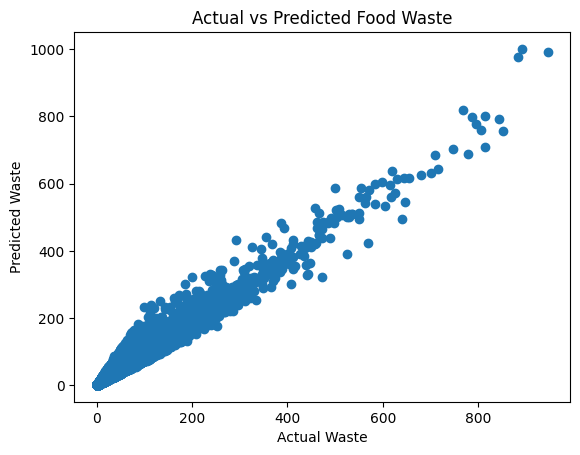

In [ ]:
import matplotlib.pyplot as plt

pred = rf.predict(X_test)

plt.scatter(y_test, pred)

plt.xlabel("Actual Waste")
plt.ylabel("Predicted Waste")

plt.title("Actual vs Predicted Food Waste")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

importance = gb.feature_importances_

features = X.columns

feature_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_df)

                  Feature  Importance
8              attendance    0.907528
21      rolling_avg_waste    0.064886
20         prev_day_waste    0.022492
3                 meal_id    0.002983
0                      id    0.000402
5              base_price    0.000351
1                    week    0.000275
4          checkout_price    0.000211
2               center_id    0.000163
14                op_area    0.000146
10                cuisine    0.000126
9           food_category    0.000120
15            day_of_week    0.000076
12            region_code    0.000056
18        is_special_meal    0.000053
6   emailer_for_promotion    0.000052
11              city_code    0.000044
7       homepage_featured    0.000012
19                weather    0.000010
17            exam_period    0.000006
16             is_weekend    0.000005
13            center_type    0.000003


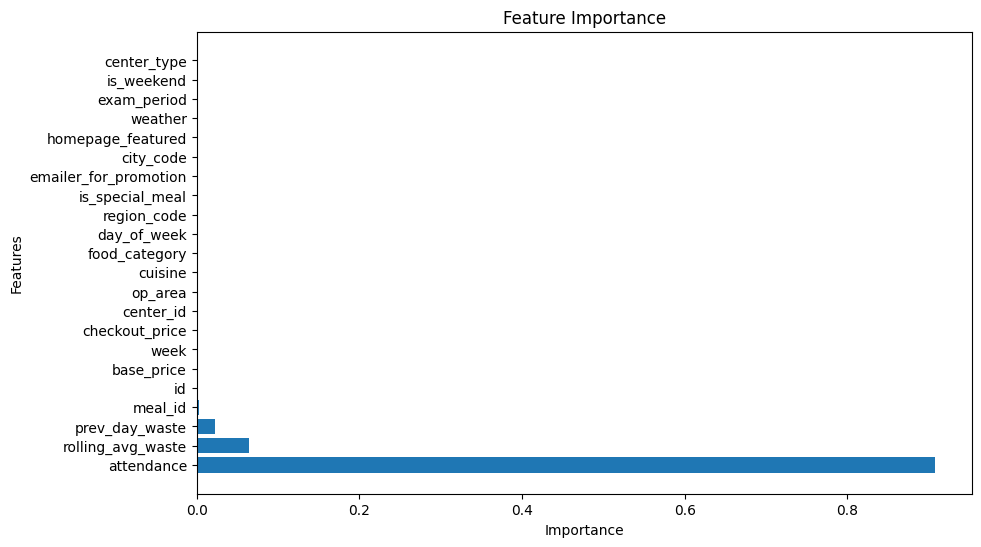

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_df['Feature'],
    feature_df['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Features")

plt.title("Feature Importance")

plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    gb,
    X_train,
    y_train,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

print(scores)
print("Average R2:", scores.mean())

[0.96155895 0.96015834 0.95854741]
Average R2: 0.9600882329760848


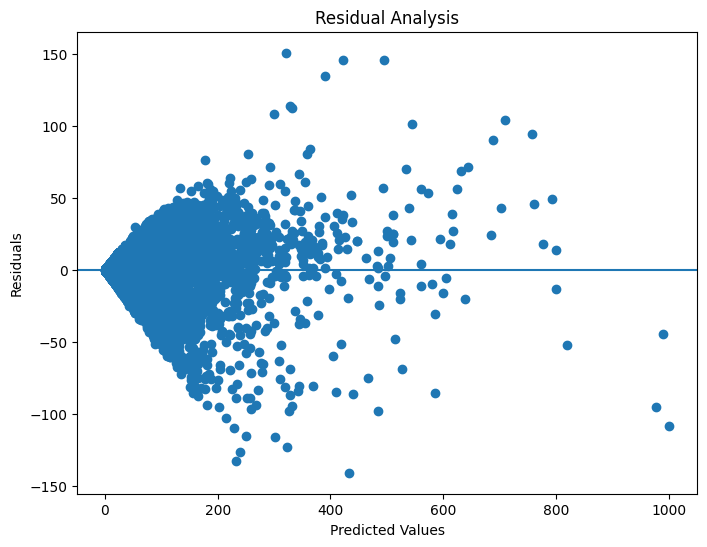

In [ ]:
residuals = y_test - pred

plt.figure(figsize=(8,6))

plt.scatter(pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Analysis")

plt.show()

In [ ]:
import joblib

joblib.dump(gb, "mess_food_waste_model.pkl")

['mess_food_waste_model.pkl']

In [ ]:
joblib.dump(X.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [ ]:
print(X.columns.tolist())

['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'attendance', 'food_category', 'cuisine', 'city_code', 'region_code', 'center_type', 'op_area', 'day_of_week', 'is_weekend', 'exam_period', 'is_special_meal', 'weather', 'prev_day_waste', 'rolling_avg_waste']


In [ ]:
sample = X_test.iloc[[0]]

prediction = gb.predict(sample)

print(sample)

print("\nPredicted Waste:",
      prediction[0])

            id  week  center_id  meal_id  checkout_price  base_price  \
98198  1373230    34         81     2126          551.93      534.53   

       emailer_for_promotion  homepage_featured  attendance  food_category  \
98198                      0                  1          26              6   

       ...  region_code  center_type  op_area  day_of_week  is_weekend  \
98198  ...           34            0      4.0            6           1   

       exam_period  is_special_meal  weather  prev_day_waste  \
98198            0                0        0        6.202807   

       rolling_avg_waste  
98198           3.169053  

[1 rows x 22 columns]

Predicted Waste: 2.634156909526144
